# Check the EFA settings in the new RAW reports
This notebook tests the *reported component hypotheses*, not assumed biological species counts. It repeats forward/backward EFA and constrained rotation over both the full recorded q range and q=0.012–0.25 Å⁻¹. The report's selected profiles are not supplied, so this is a reconstruction of its stated settings from the repository HDF5 series, **not an exact reproduction of the report's RAW session**.

WT: overall frames 130–200; four proposed supports 130–154, 130–194, 154–195, 155–195. AA: overall frames 117–250; three supports 160–222, 168–197, 168–222. All bounds are inclusive.

The PDF WT buffer range (210–239) differs from the notebook (220–236). Both reports list endpoint linear baseline windows 0–10 and 439–449. Here we reconstruct a weighted line after constant residual-buffer subtraction, and propagate its prediction variance. Since fitting a line includes an intercept, the constant subtraction cancels in the final intensities for fixed weights; its effect on weighting remains. Facility-subtraction covariance cannot be reconstructed from the supplied data.

In [1]:
from pathlib import Path
import sys, json, hashlib
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image
ROOT=Path.cwd()
sys.path.insert(0,str(ROOT/'analysis'))
from inspect_data import load, correct
from select_windows import average
from run_efa import guinier
%matplotlib inline

import raw_efa_core as efa


## Reconstruct the stated background model
For q bin i, fit $y_i(t)=\alpha_i+\beta_i t$ to the endpoint windows. With $x_t=(1,t)^T$, the corrected mean is $y_i(t)-x_t^T\hat\beta_i$. The added baseline variance is $x_t^T\mathrm{Cov}(\hat\beta_i)x_t$, and the covariance between two corrected frames includes $x_t^T\mathrm{Cov}(\hat\beta_i)x_u$. SVD row scaling below is an approximation to noise weighting, not full whitening of that covariance.

In [2]:
def report_background(name):
    q,Y,E=load(name)
    a,b=(210,239) if name.startswith('WT') else (24,70)
    bg=Y[:,a:b+1].mean(1)
    bgv=(E[:,a:b+1]**2).sum(1)/(b-a+1)**2
    Y0=Y-bg[:,None]; E0=np.sqrt(E**2+bgv[:,None])
    idx=np.r_[0:11,439:450]; X=np.c_[np.ones(len(idx)),idx]
    T=np.c_[np.ones(Y.shape[1]),np.arange(Y.shape[1])]
    out=Y0.copy(); err=E.copy()
    for j in range(len(q)):
        w=1/E0[j,idx]**2
        cov=np.linalg.inv(X.T@(w[:,None]*X))
        beta=cov@(X.T@(w*Y0[j,idx]))
        out[j]-=T@beta
        err[j]=np.sqrt(E[j]**2+np.einsum('ij,jk,ik->i',T,cov,T))
    return q,out,err
specs=[('WT_092025',130,200,[[130,154],[130,194],[154,195],[155,195]]),
       ('AA_052026',117,250,[[160,222],[168,197],[168,222]])]


## SVD, evolving factors, and rotation
$$A_{it}=D_{it}/\bar\sigma_i,\qquad A=U\Sigma V^T.$$
Forward EFA computes the singular values of $A_{:,0:t}$; backward EFA uses $A_{:,t:T}$. Supports inferred from these curves constrain component elution profiles. A rotation of the retained subspace can give $A\approx S_w C^T$, but overlapping supports can make that rotation poorly determined. Smooth singular vectors, residual structure, positivity, and stability across ranges all matter.

The code below uses RAW's numerical EFA/rotation functions, included with their GPL license. It records convergence and negative scattering values, instead of equating convergence with physical validity.

{'sample': 'WT_092025', 'q': [0.006, 3.190000000000002], 'frames': [130, 200], 'supports': [[130, 154], [130, 194], [154, 195], [155, 195]], 'singular_values': [815.3122503361881, 60.8630161163676, 18.623865580026212, 17.508643570971596, 16.791447035605373, 16.386300039523814, 15.93831025595419, 15.775067496943302], 'converged': True, 'iterations': 1690, 'concentration_condition': 42.21113227128277, 'negative_profile_fraction': [0.1978021978021978, 0.02564102564102564, 0.5238095238095238, 0.5018315018315018], 'residual_ms': 0.4853839208312543}
{'sample': 'WT_092025', 'q': [0.012, 0.25], 'frames': [130, 200], 'supports': [[130, 154], [130, 194], [154, 195], [155, 195]], 'singular_values': [804.5557880339743, 53.464534673979216, 15.20632837626008, 14.883607051249728, 14.371039234985554, 14.108600436998138, 13.750684516130292, 13.26556572599779], 'converged': False, 'iterations': 3000}


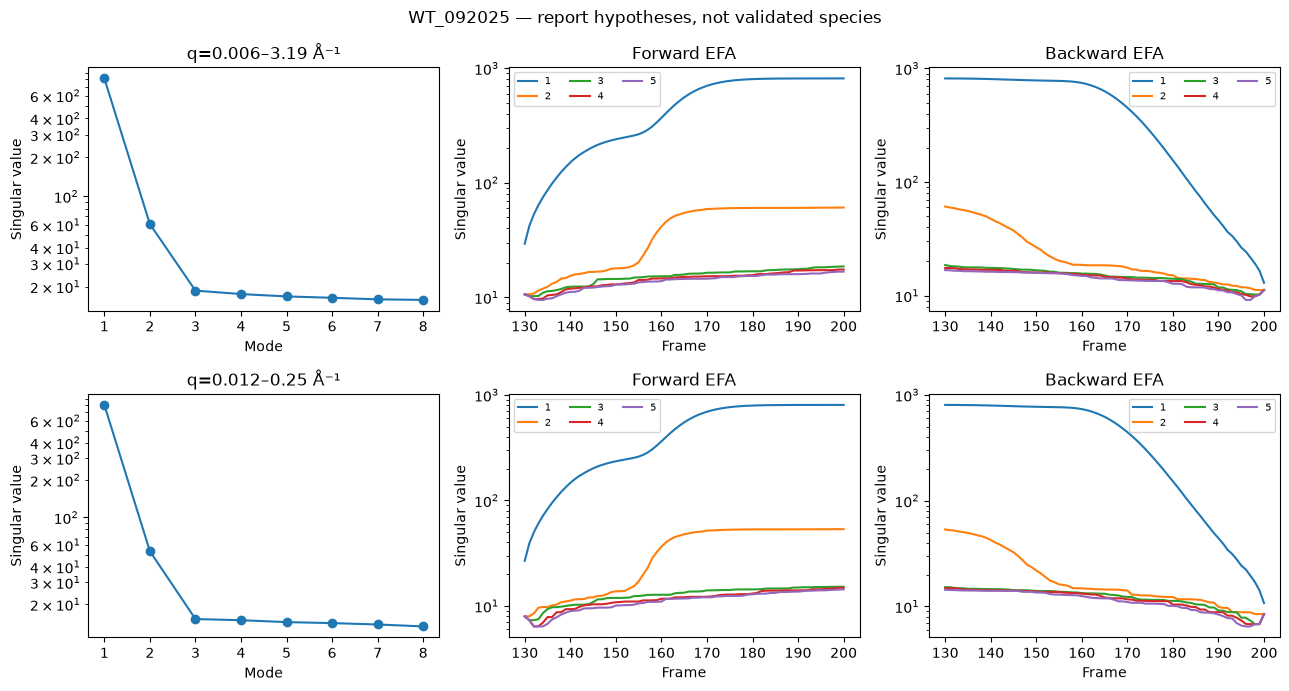

{'sample': 'AA_052026', 'q': [0.005, 3.190000000000002], 'frames': [117, 250], 'supports': [[160, 222], [168, 197], [168, 222]], 'singular_values': [1773.9421766644587, 29.44212534593773, 18.022184769078347, 17.717151143601523, 17.29309167690326, 17.151327066097082, 16.957822952570037, 16.660344962694158], 'converged': True, 'iterations': 820, 'concentration_condition': 35.55163096811855, 'negative_profile_fraction': [0.145985401459854, 0.5985401459854015, 0.46715328467153283], 'residual_ms': 0.3805696558192477}
{'sample': 'AA_052026', 'q': [0.012, 0.25], 'frames': [117, 250], 'supports': [[160, 222], [168, 197], [168, 222]], 'singular_values': [1725.566486257557, 20.049591623381342, 15.48749660617011, 15.141178137832485, 14.847121509938376, 14.503434306608264, 14.06316645393251, 13.884297493701952], 'converged': True, 'iterations': 407, 'concentration_condition': 11.427369297354206, 'negative_profile_fraction': [0.0, 0.6344086021505376, 0.6129032258064516], 'residual_ms': 0.5729169620

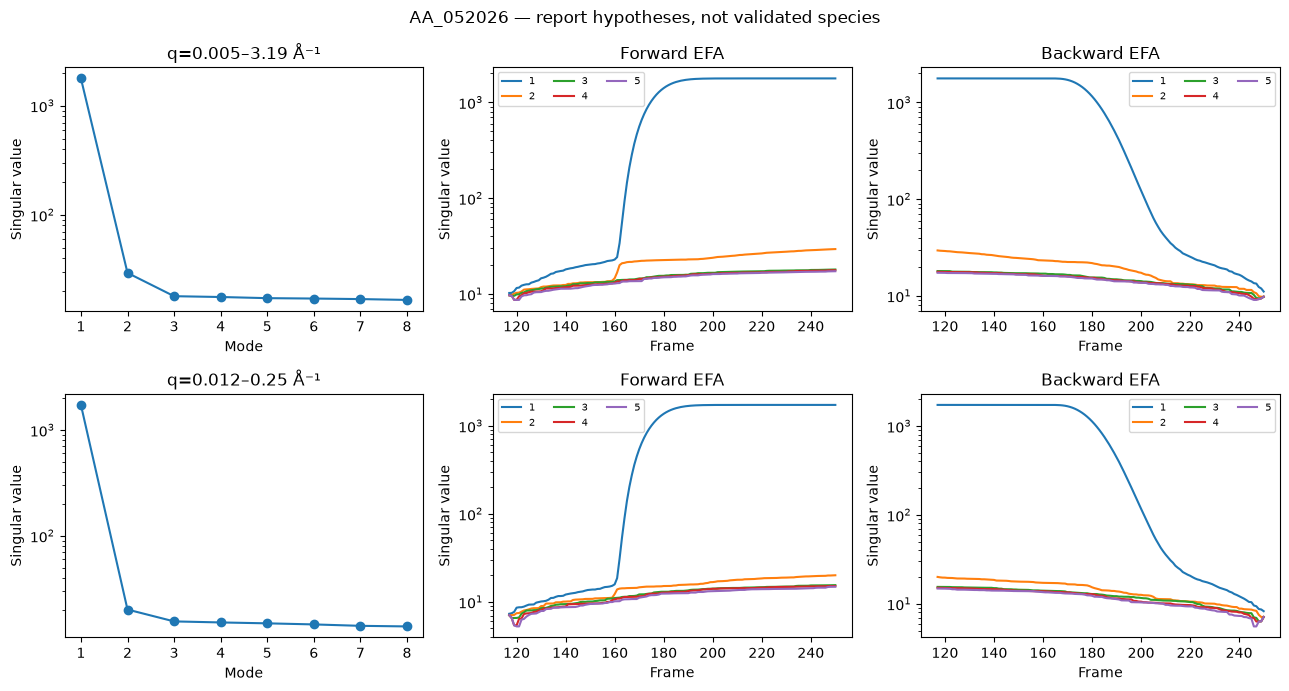

In [3]:
results=[]
for name,a,b,supports in specs:
    q,Y,E=report_background(name)
    fig,axes=plt.subplots(2,3,figsize=(13,7))
    for row,(lo,hi) in enumerate([(float(q[0]),float(q[-1])),(.012,.25)]):
        m=(q>=lo)&(q<=hi); err=E[m,a:b+1]; w=err.mean(1)
        D=Y[m,a:b+1]/w[:,None]
        U,s,Vt=np.linalg.svd(D,full_matrices=False)
        fw=efa.runEFA(D); bw=efa.runEFA(D,False)[:,::-1]
        frames=np.arange(a,b+1)
        axes[row,0].semilogy(np.arange(1,9),s[:8],'o-')
        axes[row,0].set(title=f'q={lo:g}–{hi:g} Å⁻¹',xlabel='Mode',ylabel='Singular value')
        for k in range(min(5,len(s))):
            axes[row,1].semilogy(frames,fw[k],label=str(k+1))
            axes[row,2].semilogy(frames,bw[k],label=str(k+1))
        axes[row,1].set(title='Forward EFA',xlabel='Frame',ylabel='Singular value')
        axes[row,2].set(title='Backward EFA',xlabel='Frame',ylabel='Singular value')
        for ax in axes[row,1:]: ax.legend(fontsize=7,ncol=3)
        with np.errstate(all='ignore'):
            ok,conv,rot=efa.runRotation(D,Y[m,a:b+1],err,np.array(supports)-a,
                                        [True]*len(supports),Vt.T,niter=3000,tol=1e-9)
        r=dict(sample=name,q=[lo,hi],frames=[a,b],supports=supports,
               singular_values=s[:8].tolist(),converged=bool(ok),iterations=conv['iterations'])
        if ok:
            C=rot['M']*rot['C']; S=Y[m,a:b+1]@np.linalg.pinv(C.T)
            r.update(concentration_condition=float(np.linalg.cond(C)),
                     negative_profile_fraction=np.mean(S<0,axis=0).tolist(),
                     residual_ms=float(np.mean(((Y[m,a:b+1]-S@C.T)/err)**2)))
            np.savez_compressed(ROOT/'results'/f'{name}_report_rotation_{row}.npz',q=q[m],frames=frames,C=C,S=S,error=err)
        results.append(r)
        print(r)
    fig.suptitle(name+' — report hypotheses, not validated species')
    fig.tight_layout(); fig.savefig(ROOT/'results'/f'{name}_report_efa.png',dpi=170)
    display(fig);plt.close(fig)
(ROOT/'results/report_EFA_sensitivity.json').write_text(json.dumps(results,indent=2));


## Inspect the recovered curves
Negative values can be ordinary high-q noise, but large negative fractions or ill-conditioned, nearly collinear elution profiles undermine a unique species assignment. Full-q backgrounds may introduce modes unrelated to protein conformations. Restricting q also loses information, so it is a sensitivity check, not a guarantee of a correct answer.

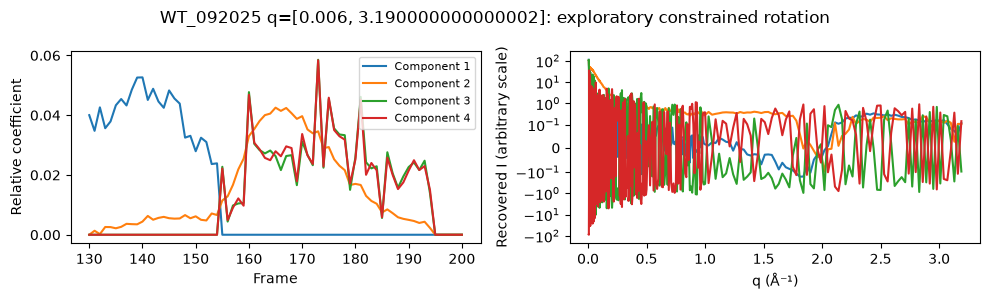

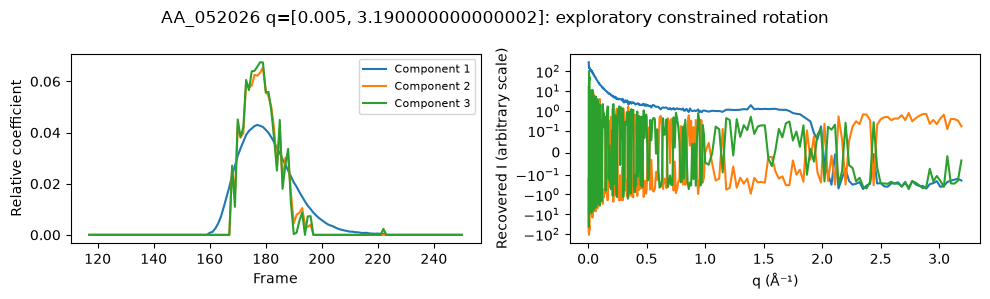

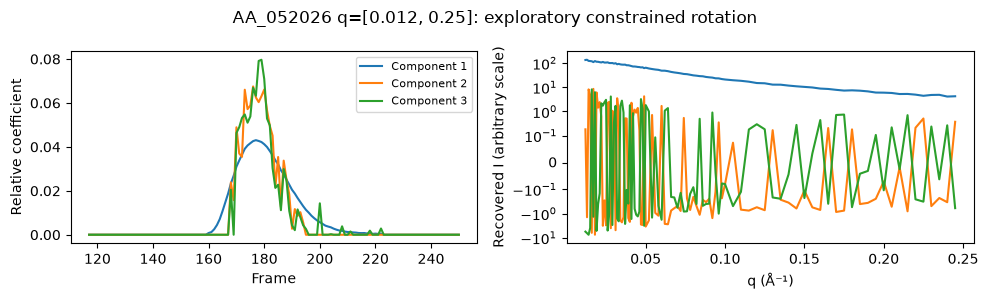

In [4]:
for r in results:
    if not r['converged']: continue
    row=0 if r['q'][1]>.3 else 1
    d=np.load(ROOT/'results'/f"{r['sample']}_report_rotation_{row}.npz")
    fig,ax=plt.subplots(1,2,figsize=(10,3))
    for k in range(d['C'].shape[1]):
        ax[0].plot(d['frames'],d['C'][:,k],label=f'Component {k+1}')
        ax[1].plot(d['q'],d['S'][:,k],label=f'Component {k+1}')
    ax[0].set(xlabel='Frame',ylabel='Relative coefficient');ax[0].legend(fontsize=8)
    ax[1].set(xlabel='q (Å⁻¹)',ylabel='Recovered I (arbitrary scale)'); ax[1].set_yscale('symlog',linthresh=.1)
    fig.suptitle(f"{r['sample']} q={r['q']}: exploratory constrained rotation")
    fig.tight_layout();display(fig);plt.close(fig)


## What this can establish
The source reports contain proposed component counts. They do not provide independent molecular weights. A species assignment requires stable separation with plausible scattering profiles, defensible uncertainties and additional evidence. EFA cannot distinguish monomer and oligomer when their elution is identical or their scattering curves are indistinguishable in the measured range.

For a mixture, the low-q slope gives
$$R_{g,\mathrm{app}}^2=\frac{\sum_k I_k(0)R_{g,k}^2}{\sum_k I_k(0)}.$$
Consequently, an Rg value alone cannot determine oligomer fractions. Read the clean-region/noise sensitivity results in notebook 02 before interpreting the constrained rotations here.